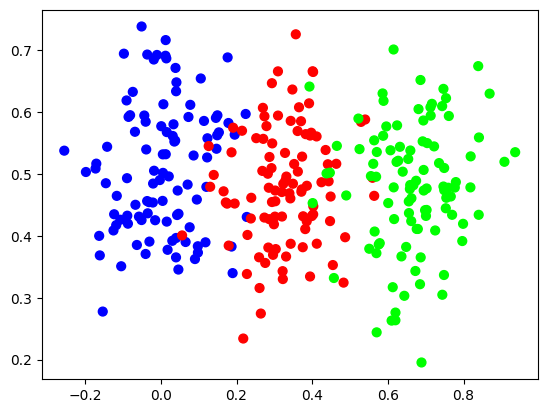

In [3]:
# simpler dataset
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()

In [5]:
import numpy as np

In [6]:
class DenseLayer:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

In [7]:
# ReLU activation class
class ReLUActivation:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

In [8]:
class SoftmaxActivation:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities

In [9]:
class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss

In [10]:
# common loss class
class Loss_CategoricalCrossEntropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples), y_true
            ]
        
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true, axis=1
            )
        
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods 

<h3>Strategy1: Randomly selection weights and biases</h3>

In [11]:
X, y = vertical_data(samples=100, classes=3)

dense1 = DenseLayer(2, 3)
activation1 = ReLUActivation()

dense2 = DenseLayer(3, 3)
activation2 = SoftmaxActivation()

loss_function = Loss_CategoricalCrossEntropy()

In [12]:
lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

In [19]:
for iteration in range(100000):
    dense1.weights = 0.05 * np.random.randn(2,3)
    dense1.biases = 0.05 * np.random.randn(1,3)
    dense2.weights = 0.05 * np.random.randn(3,3)
    dense2.biases = 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output, y)
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New sets of weights found, iteration", iteration, "loss", loss, "acc:", accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss

New sets of weights found, iteration 4 loss 1.0978699 acc: 0.3333333333333333
New sets of weights found, iteration 36 loss 1.0977035 acc: 0.3333333333333333
New sets of weights found, iteration 65 loss 1.0968316 acc: 0.3333333333333333
New sets of weights found, iteration 3641 loss 1.0966569 acc: 0.6333333333333333
New sets of weights found, iteration 12564 loss 1.0963852 acc: 0.3333333333333333
New sets of weights found, iteration 15497 loss 1.0962396 acc: 0.3333333333333333
New sets of weights found, iteration 27254 loss 1.096165 acc: 0.3333333333333333
New sets of weights found, iteration 27284 loss 1.0959749 acc: 0.3333333333333333
New sets of weights found, iteration 51888 loss 1.0956644 acc: 0.3333333333333333
New sets of weights found, iteration 74206 loss 1.0951802 acc: 0.3333333333333333


Does not seem to work as loss never reduces.

<h3>Strategy2: Adjusting weights and biases</h3>

In [20]:
X, y = vertical_data(samples=100, classes=3)

dense1 = DenseLayer(2, 3)
activation1 = ReLUActivation()

dense2 = DenseLayer(3, 3)
activation2 = SoftmaxActivation()

loss_function = Loss_CategoricalCrossEntropy()

In [21]:
lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

In [22]:
for iteration in range(100000):
    dense1.weights += 0.05 * np.random.randn(2,3)
    dense1.biases += 0.05 * np.random.randn(1,3)
    dense2.weights += 0.05 * np.random.randn(3,3)
    dense2.biases += 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output, y)
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New sets of weights found, iteration", iteration, "loss", loss, "acc:", accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1_weights = best_dense1_weights.copy()
        dense1_biases = best_dense1_biases.copy()
        dense2_weights = best_dense2_weights.copy()
        dense2_biases = best_dense2_biases.copy()

New sets of weights found, iteration 0 loss 1.0995655 acc: 0.3333333333333333
New sets of weights found, iteration 17 loss 1.0969623 acc: 0.6233333333333333
New sets of weights found, iteration 18 loss 1.0966926 acc: 0.5
New sets of weights found, iteration 995 loss 1.0874422 acc: 0.37
New sets of weights found, iteration 996 loss 1.0246851 acc: 0.52
New sets of weights found, iteration 1006 loss 1.0122253 acc: 0.36666666666666664
New sets of weights found, iteration 1007 loss 0.95753187 acc: 0.44333333333333336
New sets of weights found, iteration 1029 loss 0.95684934 acc: 0.4
New sets of weights found, iteration 1030 loss 0.8848342 acc: 0.46
New sets of weights found, iteration 1032 loss 0.8341675 acc: 0.49666666666666665
New sets of weights found, iteration 1040 loss 0.7519337 acc: 0.6666666666666666
New sets of weights found, iteration 1041 loss 0.7288277 acc: 0.56
New sets of weights found, iteration 1042 loss 0.66088885 acc: 0.7533333333333333


Looks like it works, but let's check for spiral data

In [24]:
from nnfs.datasets import spiral_data
X, y = spiral_data(samples=100, classes=3)

dense1 = DenseLayer(2, 3)
activation1 = ReLUActivation()

dense2 = DenseLayer(3, 3)
activation2 = SoftmaxActivation()

loss_function = Loss_CategoricalCrossEntropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights += 0.05 * np.random.randn(2,3)
    dense1.biases += 0.05 * np.random.randn(1,3)
    dense2.weights += 0.05 * np.random.randn(3,3)
    dense2.biases += 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output, y)
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New sets of weights found, iteration", iteration, "loss", loss, "acc:", accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1_weights = best_dense1_weights.copy()
        dense1_biases = best_dense1_biases.copy()
        dense2_weights = best_dense2_weights.copy()
        dense2_biases = best_dense2_biases.copy()

New sets of weights found, iteration 0 loss 1.0997928 acc: 0.3333333333333333
New sets of weights found, iteration 2 loss 1.0991302 acc: 0.3333333333333333
New sets of weights found, iteration 3 loss 1.0977366 acc: 0.3233333333333333
New sets of weights found, iteration 18 loss 1.0928359 acc: 0.4166666666666667
New sets of weights found, iteration 20 loss 1.0927523 acc: 0.37333333333333335
New sets of weights found, iteration 23 loss 1.0908571 acc: 0.38333333333333336
New sets of weights found, iteration 24 loss 1.0903504 acc: 0.36666666666666664
New sets of weights found, iteration 25 loss 1.0901697 acc: 0.38666666666666666
New sets of weights found, iteration 26 loss 1.0882252 acc: 0.4266666666666667
New sets of weights found, iteration 36 loss 1.0873026 acc: 0.37666666666666665


Looks like it does not work for spiral data as loss is not getting down.